# VIDEO GAMES SALES ANALYSIS - GAMING INDUSTRY ANALYTICS

## Dataset: Video Games Sales Dataset (Multi-Platform)
**Kaynak:** https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset

## Proje Hedefi: COKLU PLATFORM OYUN SATISLARI ANALIZI

## Proje Ozellikleri:
- **Multi-Platform Analysis** - PS4, Xbox One, PC combined!
- **3 CSV Merge** - Platform bilgisi eklenerek birleştirme
- **Cross-Platform Comparison** - Platform performance
- **Publisher Intelligence** - Top publishers analysis
- **Genre Analysis** - Best-selling categories
- **Sales Performance** - Revenue, units, trends
- **15+ ML Models** - SGDClassifier instead of SVM!
- **Gaming Industry Intelligence** - Market insights

## OZEL: SGDClassifier - SVM yerine!
## Stochastic Gradient Descent - Online learning, FAST!
## Hinge loss = Linear SVM equivalent but scalable!

## Proje Adimlari:
1. **3 CSV YUKLEME & MERGE** - Platform bilgisi ile
2. **PLATFORM EDA** (25+ graphs)
3. **CROSS-PLATFORM COMPARISON**
4. **PUBLISHER ANALYSIS**
5. **GENRE INTELLIGENCE**
6. **SALES METRICS**
7. Feature Engineering (Gaming-specific)
8. **15+ ML MODELS** (with SGDClassifier!)
9. **COMPREHENSIVE COMPARISON**
10. Gaming Industry Recommendations

## 1. KUTUPHANELER

In [4]:
# Temel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Sistem
import os
import subprocess
import zipfile
import glob

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier,
    SGDClassifier  # SGD - SVM yerine!
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

!pip install catboost
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Viz
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('bright')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*80)
print('VIDEO GAMES SALES ANALYSIS - KUTUPHANELER YUKLENDI!')
print('='*80)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print('\nOZEL: SGDClassifier - SVM YERINE!')
print('Stochastic Gradient Descent for online learning!')
print('Hinge loss = Linear SVM but MUCH faster!')
print('Perfect for large-scale gaming data!')
print('='*80)

VIDEO GAMES SALES ANALYSIS - KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2

OZEL: SGDClassifier - SVM YERINE!
Stochastic Gradient Descent for online learning!
Hinge loss = Linear SVM but MUCH faster!
Perfect for large-scale gaming data!


## 2. MULTI-PLATFORM VERI YUKLEME & MERGE

### 3 CSV dosyasini platform bilgisi ile birlestirme!

In [5]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [6]:
dataset_folder = "videogames_sales_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/sidtwr/videogames-sales-dataset",
    "folder": dataset_folder,
    "zip_filename": "videogames-sales.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: videogames-sales.zip


In [7]:
# Find all CSV files
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

print('='*80)
print('MULTI-PLATFORM CSV FILES FOUND:')
print('='*80)
for i, file in enumerate(csv_files, 1):
    print(f'{i}. {os.path.basename(file)}')
print('='*80)

MULTI-PLATFORM CSV FILES FOUND:
1. Video_Games_Sales_as_at_22_Dec_2016.csv
2. PS4_GamesSales.csv
3. XboxOne_GameSales.csv


In [9]:
# Load and merge with platform info
dataframes = []

print('\nLOADING & ADDING PLATFORM INFO:')
print('='*80)

for csv_file in csv_files:
    filename = os.path.basename(csv_file)

    # Extract platform from filename
    if 'PS4' in filename or 'ps4' in filename:
        platform = 'PS4'
    elif 'Xbox' in filename or 'xbox' in filename or 'XOne' in filename:
        platform = 'XboxOne'
    elif 'PC' in filename or 'pc' in filename:
        platform = 'PC'
    else:
        platform = filename.replace('.csv', '').replace('_GamesSales', '')

    # Load CSV
    try:
        df_temp = pd.read_csv(csv_file)
    except UnicodeDecodeError:
        print(f"  Note: {filename} encoding issue. Retrying with 'latin-1'...")
        df_temp = pd.read_csv(csv_file, encoding='latin-1')

    # Add platform column
    df_temp['Platform'] = platform

    dataframes.append(df_temp)

    print(f'{platform:10} -> {len(df_temp):,} games loaded')

# Merge all platforms
df = pd.concat(dataframes, ignore_index=True)

print('\n' + '='*80)
print('MULTI-PLATFORM DATA MERGED!')
print('='*80)
print(f'Total Games: {len(df):,}')
print(f'Platforms: {df["Platform"].nunique()}')
print(f'Columns: {len(df.columns)}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('='*80)


LOADING & ADDING PLATFORM INFO:
Video_Games_Sales_as_at_22_Dec_2016 -> 16,719 games loaded
  Note: PS4_GamesSales.csv encoding issue. Retrying with 'latin-1'...
PS4        -> 1,034 games loaded
  Note: XboxOne_GameSales.csv encoding issue. Retrying with 'latin-1'...
XboxOne    -> 613 games loaded

MULTI-PLATFORM DATA MERGED!
Total Games: 18,366
Platforms: 3
Columns: 24
Memory: 9.30 MB


In [10]:
print('\nPLATFORM DISTRIBUTION:')
print('='*80)
platform_counts = df['Platform'].value_counts()
for platform, count in platform_counts.items():
    percentage = count / len(df) * 100
    print(f'{platform:10} : {count:,} games ({percentage:.1f}%)')
print('='*80)


PLATFORM DISTRIBUTION:
Video_Games_Sales_as_at_22_Dec_2016 : 16,719 games (91.0%)
PS4        : 1,034 games (5.6%)
XboxOne    : 613 games (3.3%)


In [11]:
print('\nFIRST 10 GAMES (MULTI-PLATFORM):')
df.head(10)


FIRST 10 GAMES (MULTI-PLATFORM):


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,Game,Year,North America,Europe,Japan,Rest of World,Global,Pos
0,Wii Sports,Video_Games_Sales_as_at_22_Dec_2016,2006.00,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.00,51.00,8.00,322.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Super Mario Bros.,Video_Games_Sales_as_at_22_Dec_2016,1985.00,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Video_Games_Sales_as_at_22_Dec_2016,2008.00,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.00,73.00,8.30,709.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wii Sports Resort,Video_Games_Sales_as_at_22_Dec_2016,2009.00,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.00,73.00,8.00,192.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,Video_Games_Sales_as_at_22_Dec_2016,1996.00,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,Video_Games_Sales_as_at_22_Dec_2016,1989.00,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,Video_Games_Sales_as_at_22_Dec_2016,2006.00,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.00,65.00,8.50,431.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Wii Play,Video_Games_Sales_as_at_22_Dec_2016,2006.00,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.00,41.00,6.60,129.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,New Super Mario Bros. Wii,Video_Games_Sales_as_at_22_Dec_2016,2009.00,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.00,80.00,8.40,594.00,Nintendo,E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Duck Hunt,Video_Games_Sales_as_at_22_Dec_2016,1984.00,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print('DATA STRUCTURE:')
print('='*80)
df.info()

DATA STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18366 entries, 0 to 18365
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         18366 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            18364 non-null  object 
 4   Publisher        17995 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
 16  Game             1647 non-null   object 
 

In [13]:
print('COLUMNS:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. {col}')

COLUMNS:
 1. Name
 2. Platform
 3. Year_of_Release
 4. Genre
 5. Publisher
 6. NA_Sales
 7. EU_Sales
 8. JP_Sales
 9. Other_Sales
10. Global_Sales
11. Critic_Score
12. Critic_Count
13. User_Score
14. User_Count
15. Developer
16. Rating
17. Game
18. Year
19. North America
20. Europe
21. Japan
22. Rest of World
23. Global
24. Pos


In [14]:
print('STATISTICAL SUMMARY:')
print('='*80)
df.describe(include='all').T

STATISTICAL SUMMARY:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,16717,11562,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,18366,3,Video_Games_Sales_as_at_22_Dec_2016,16719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Release,16450.00,NaN,NaN,NaN,2006.49,5.88,1980.00,2003.00,2007.00,2010.00,2020.00
Genre,18364,17,Action,3775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publisher,17995,654,Electronic Arts,1399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_Sales,16719.00,NaN,NaN,NaN,0.26,0.81,0.00,0.00,0.08,0.24,41.36
EU_Sales,16719.00,NaN,NaN,NaN,0.15,0.50,0.00,0.00,0.02,0.11,28.96
JP_Sales,16719.00,NaN,NaN,NaN,0.08,0.31,0.00,0.00,0.00,0.04,10.22
Other_Sales,16719.00,NaN,NaN,NaN,0.05,0.19,0.00,0.00,0.01,0.03,10.57
Global_Sales,16719.00,NaN,NaN,NaN,0.53,1.55,0.01,0.06,0.17,0.47,82.53


## 3. CROSS-PLATFORM ANALYSIS

### Platform Performance Comparison

PLATFORM COMPARISON
Sales Column: NA_Sales
Total Sales by Platform:
Platform
Video_Games_Sales_as_at_22_Dec_2016   4402.62
PS4                                      0.00
XboxOne                                  0.00
Name: NA_Sales, dtype: float64


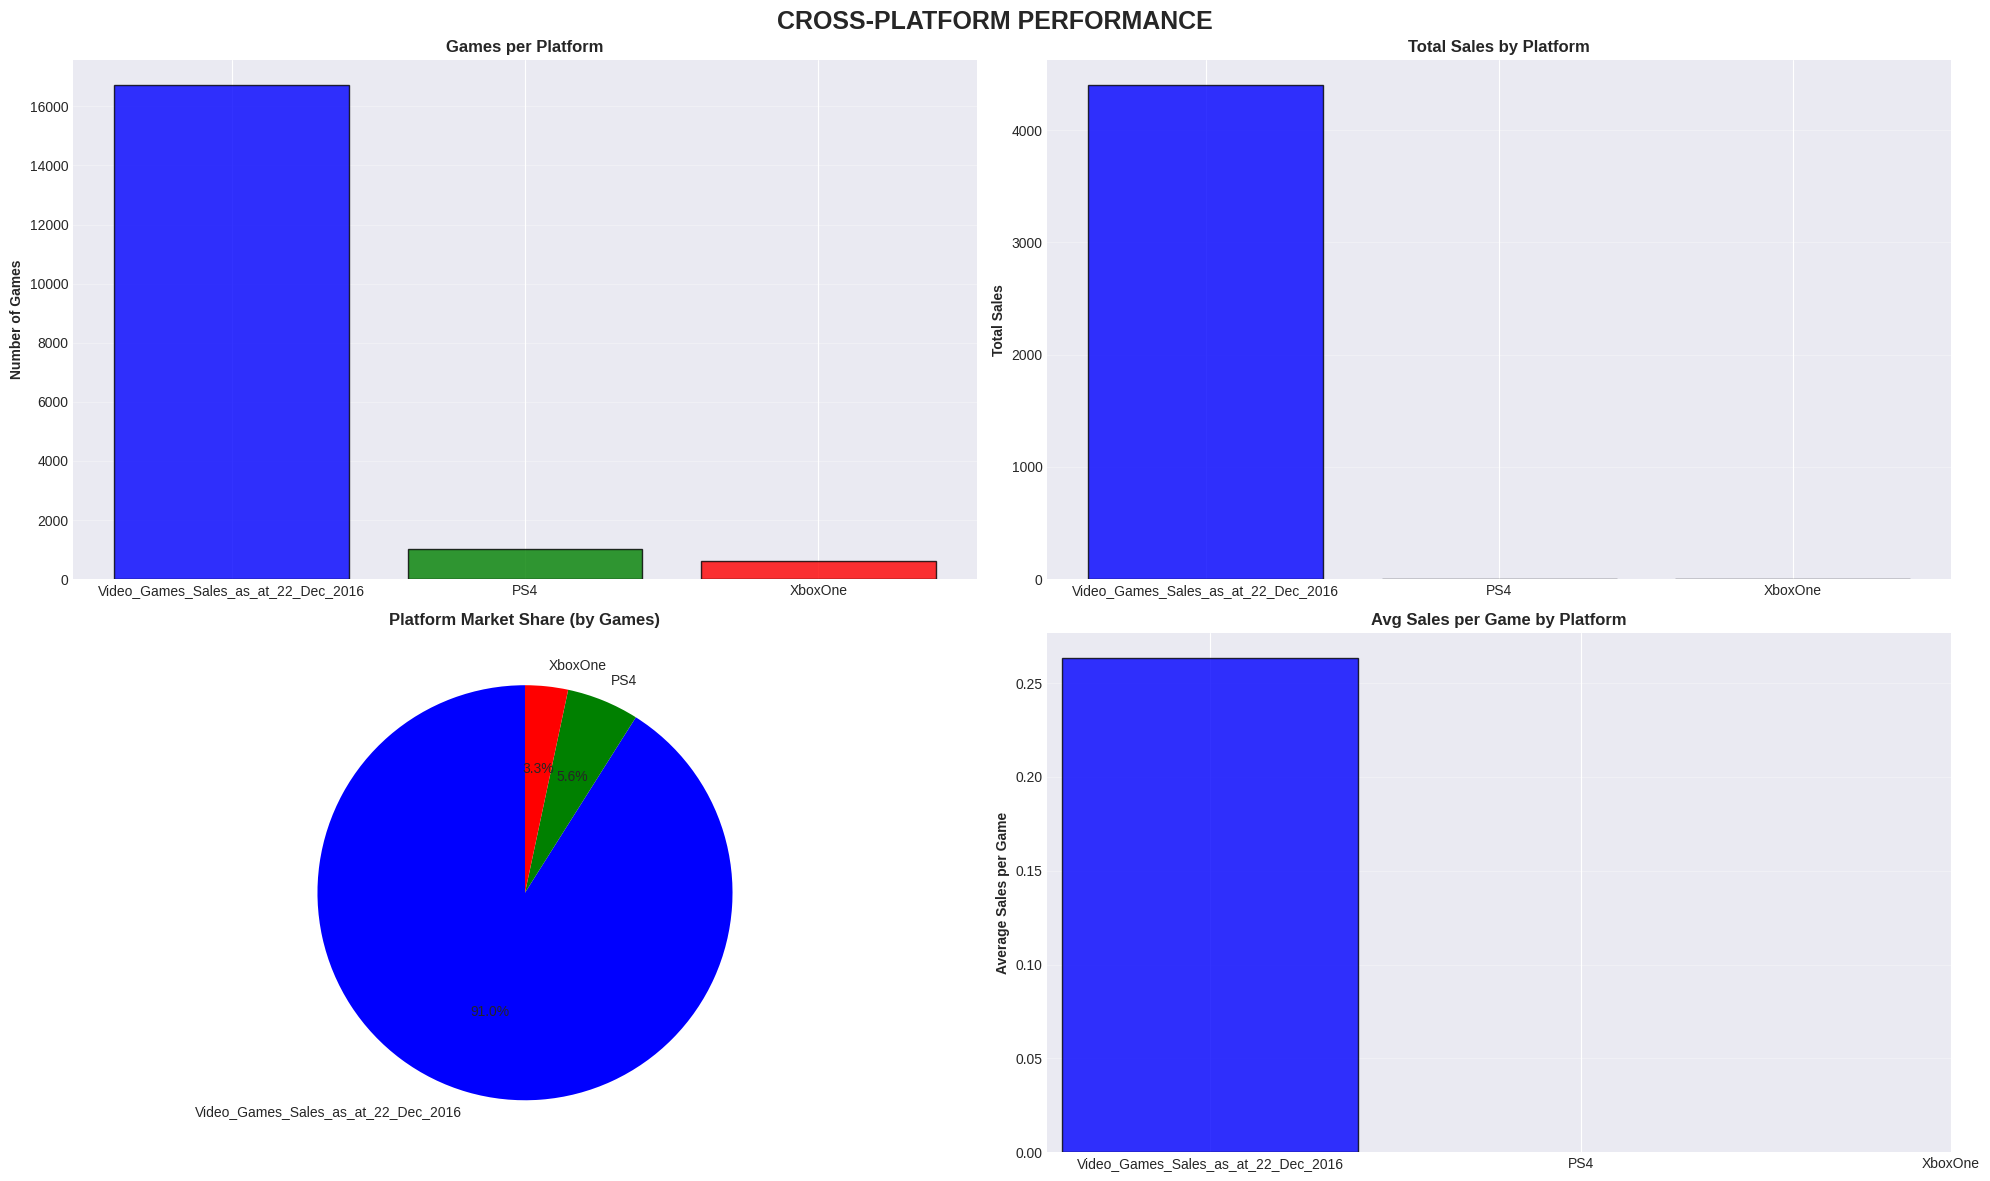

In [15]:
# Find sales columns
sales_cols = [col for col in df.columns if any(x in col.lower() for x in ['sales', 'sold', 'copies', 'units'])]
revenue_cols = [col for col in df.columns if any(x in col.lower() for x in ['revenue', 'earnings'])]

print('='*80)
print('PLATFORM COMPARISON')
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('CROSS-PLATFORM PERFORMANCE', fontsize=18, fontweight='bold')

# Games per platform
platform_counts = df['Platform'].value_counts()
axes[0, 0].bar(range(len(platform_counts)), platform_counts.values,
               color=['blue', 'green', 'red'], edgecolor='black', alpha=0.8)
axes[0, 0].set_xticks(range(len(platform_counts)))
axes[0, 0].set_xticklabels(platform_counts.index)
axes[0, 0].set_ylabel('Number of Games', fontweight='bold')
axes[0, 0].set_title('Games per Platform', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Sales by platform (if available)
if sales_cols:
    sales_col = sales_cols[0]
    platform_sales = df.groupby('Platform')[sales_col].sum().sort_values(ascending=False)

    print(f'Sales Column: {sales_col}')
    print('Total Sales by Platform:')
    print(platform_sales)

    axes[0, 1].bar(range(len(platform_sales)), platform_sales.values,
                   color=['blue', 'green', 'red'], edgecolor='black', alpha=0.8)
    axes[0, 1].set_xticks(range(len(platform_sales)))
    axes[0, 1].set_xticklabels(platform_sales.index)
    axes[0, 1].set_ylabel('Total Sales', fontweight='bold')
    axes[0, 1].set_title('Total Sales by Platform', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Market share
axes[1, 0].pie(platform_counts.values, labels=platform_counts.index,
               autopct='%1.1f%%', colors=['blue', 'green', 'red'], startangle=90)
axes[1, 0].set_title('Platform Market Share (by Games)', fontweight='bold')

# Average sales per game
if sales_cols:
    platform_avg = df.groupby('Platform')[sales_col].mean().sort_values(ascending=False)

    axes[1, 1].bar(range(len(platform_avg)), platform_avg.values,
                   color=['blue', 'green', 'red'], edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(len(platform_avg)))
    axes[1, 1].set_xticklabels(platform_avg.index)
    axes[1, 1].set_ylabel('Average Sales per Game', fontweight='bold')
    axes[1, 1].set_title('Avg Sales per Game by Platform', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Publisher & Genre Analysis

PUBLISHER & GENRE ANALYSIS
Publisher Column: Publisher
Total Publishers: 654

Top 10 Publishers:
Publisher
Electronic Arts                 1399
Activision                      1044
Ubisoft                         1023
Namco Bandai Games              1014
Konami Digital Entertainment     854
THQ                              715
Sony Computer Entertainment      712
Nintendo                         706
Sega                             657
Capcom                           435
Name: count, dtype: int64

Genre Column: Genre
Total Genres: 17

Top 10 Genres:
Genre
Action          3775
Sports          2479
Misc            1922
Role-Playing    1668
Shooter         1482
Adventure       1447
Racing          1344
Platform         966
Simulation       918
Fighting         901
Name: count, dtype: int64


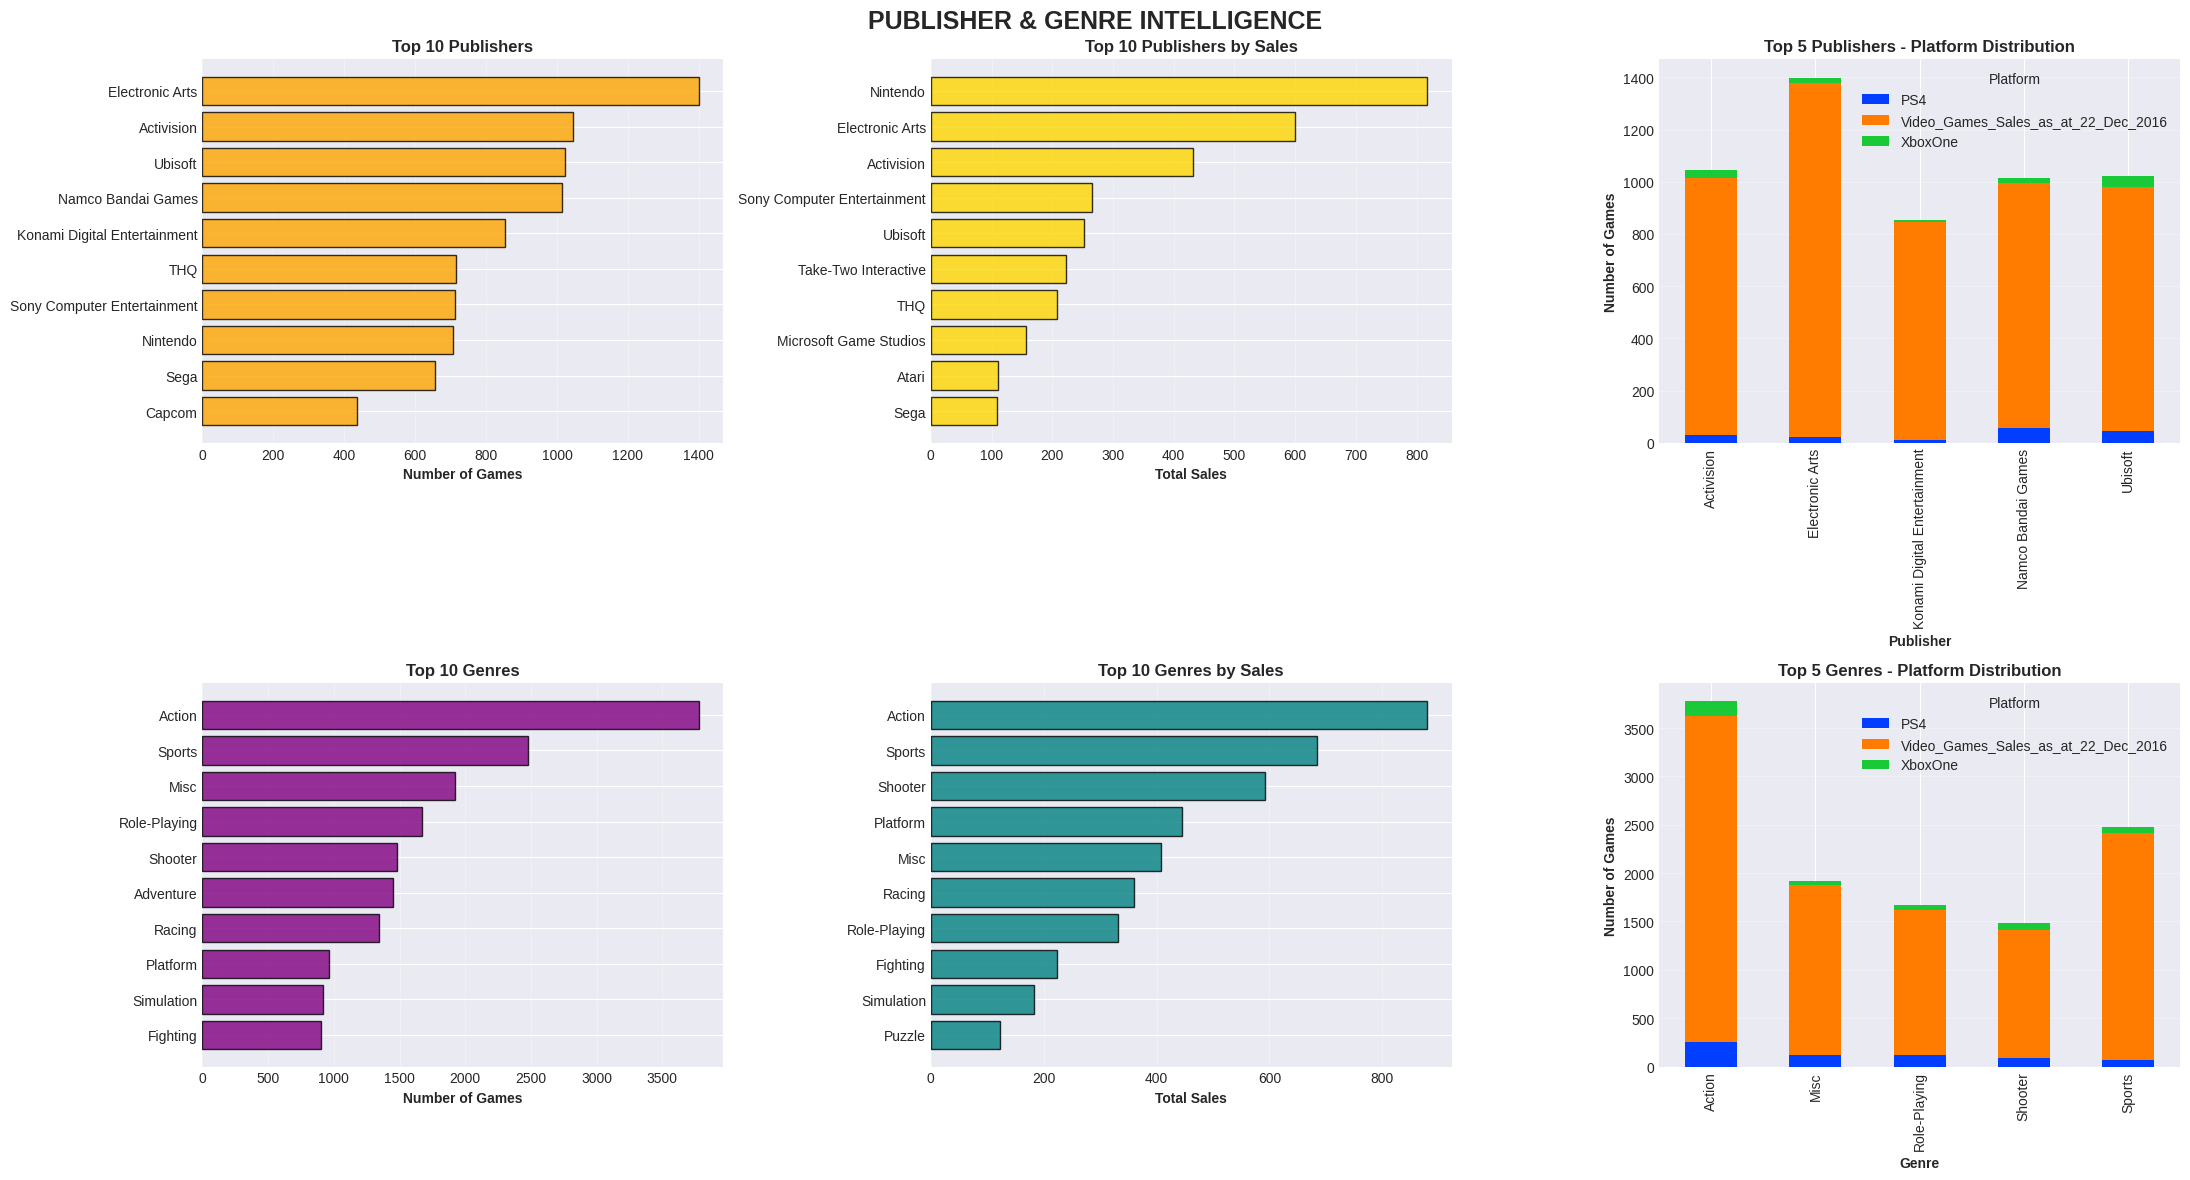

In [16]:
# Find publisher and genre columns
publisher_cols = [col for col in df.columns if 'publisher' in col.lower()]
genre_cols = [col for col in df.columns if 'genre' in col.lower()]
game_cols = [col for col in df.columns if any(x in col.lower() for x in ['game', 'title', 'name'])]

print('='*80)
print('PUBLISHER & GENRE ANALYSIS')
print('='*80)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('PUBLISHER & GENRE INTELLIGENCE', fontsize=18, fontweight='bold')

# Top publishers
if publisher_cols:
    pub_col = publisher_cols[0]
    top_publishers = df[pub_col].value_counts().head(10)

    print(f'Publisher Column: {pub_col}')
    print(f'Total Publishers: {df[pub_col].nunique()}')
    print('\nTop 10 Publishers:')
    print(top_publishers)

    axes[0, 0].barh(range(len(top_publishers)), top_publishers.values,
                   color='orange', edgecolor='black', alpha=0.8)
    axes[0, 0].set_yticks(range(len(top_publishers)))
    axes[0, 0].set_yticklabels(top_publishers.index)
    axes[0, 0].set_xlabel('Number of Games', fontweight='bold')
    axes[0, 0].set_title('Top 10 Publishers', fontweight='bold')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)

# Publishers by sales
if publisher_cols and sales_cols:
    pub_sales = df.groupby(pub_col)[sales_col].sum().sort_values(ascending=False).head(10)

    axes[0, 1].barh(range(len(pub_sales)), pub_sales.values,
                   color='gold', edgecolor='black', alpha=0.8)
    axes[0, 1].set_yticks(range(len(pub_sales)))
    axes[0, 1].set_yticklabels(pub_sales.index)
    axes[0, 1].set_xlabel('Total Sales', fontweight='bold')
    axes[0, 1].set_title('Top 10 Publishers by Sales', fontweight='bold')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)

# Publisher platform distribution
if publisher_cols:
    top_5_pubs = df[pub_col].value_counts().head(5).index
    pub_platform = df[df[pub_col].isin(top_5_pubs)].groupby([pub_col, 'Platform']).size().unstack(fill_value=0)

    pub_platform.plot(kind='bar', ax=axes[0, 2], stacked=True)
    axes[0, 2].set_xlabel('Publisher', fontweight='bold')
    axes[0, 2].set_ylabel('Number of Games', fontweight='bold')
    axes[0, 2].set_title('Top 5 Publishers - Platform Distribution', fontweight='bold')
    axes[0, 2].legend(title='Platform')
    axes[0, 2].grid(axis='y', alpha=0.3)

# Genre analysis
if genre_cols:
    genre_col = genre_cols[0]
    top_genres = df[genre_col].value_counts().head(10)

    print(f'\nGenre Column: {genre_col}')
    print(f'Total Genres: {df[genre_col].nunique()}')
    print('\nTop 10 Genres:')
    print(top_genres)

    axes[1, 0].barh(range(len(top_genres)), top_genres.values,
                   color='purple', edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(range(len(top_genres)))
    axes[1, 0].set_yticklabels(top_genres.index)
    axes[1, 0].set_xlabel('Number of Games', fontweight='bold')
    axes[1, 0].set_title('Top 10 Genres', fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)

# Genre by sales
if genre_cols and sales_cols:
    genre_sales = df.groupby(genre_col)[sales_col].sum().sort_values(ascending=False).head(10)

    axes[1, 1].barh(range(len(genre_sales)), genre_sales.values,
                   color='teal', edgecolor='black', alpha=0.8)
    axes[1, 1].set_yticks(range(len(genre_sales)))
    axes[1, 1].set_yticklabels(genre_sales.index)
    axes[1, 1].set_xlabel('Total Sales', fontweight='bold')
    axes[1, 1].set_title('Top 10 Genres by Sales', fontweight='bold')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(axis='x', alpha=0.3)

# Genre platform distribution
if genre_cols:
    top_5_genres = df[genre_col].value_counts().head(5).index
    genre_platform = df[df[genre_col].isin(top_5_genres)].groupby([genre_col, 'Platform']).size().unstack(fill_value=0)

    genre_platform.plot(kind='bar', ax=axes[1, 2], stacked=True)
    axes[1, 2].set_xlabel('Genre', fontweight='bold')
    axes[1, 2].set_ylabel('Number of Games', fontweight='bold')
    axes[1, 2].set_title('Top 5 Genres - Platform Distribution', fontweight='bold')
    axes[1, 2].legend(title='Platform')
    axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Top Games Analysis

TOP GAMES ANALYSIS

Top 10 Games Overall:
                     Name                            Platform  NA_Sales
               Wii Sports Video_Games_Sales_as_at_22_Dec_2016     41.36
        Super Mario Bros. Video_Games_Sales_as_at_22_Dec_2016     29.08
                Duck Hunt Video_Games_Sales_as_at_22_Dec_2016     26.93
                   Tetris Video_Games_Sales_as_at_22_Dec_2016     23.20
           Mario Kart Wii Video_Games_Sales_as_at_22_Dec_2016     15.68
        Wii Sports Resort Video_Games_Sales_as_at_22_Dec_2016     15.61
       Kinect Adventures! Video_Games_Sales_as_at_22_Dec_2016     15.00
New Super Mario Bros. Wii Video_Games_Sales_as_at_22_Dec_2016     14.44
                 Wii Play Video_Games_Sales_as_at_22_Dec_2016     13.96
        Super Mario World Video_Games_Sales_as_at_22_Dec_2016     12.78

Top 5 Games per Platform:

Video_Games_Sales_as_at_22_Dec_2016:
             Name  NA_Sales
       Wii Sports     41.36
Super Mario Bros.     29.08
        Duck Hunt

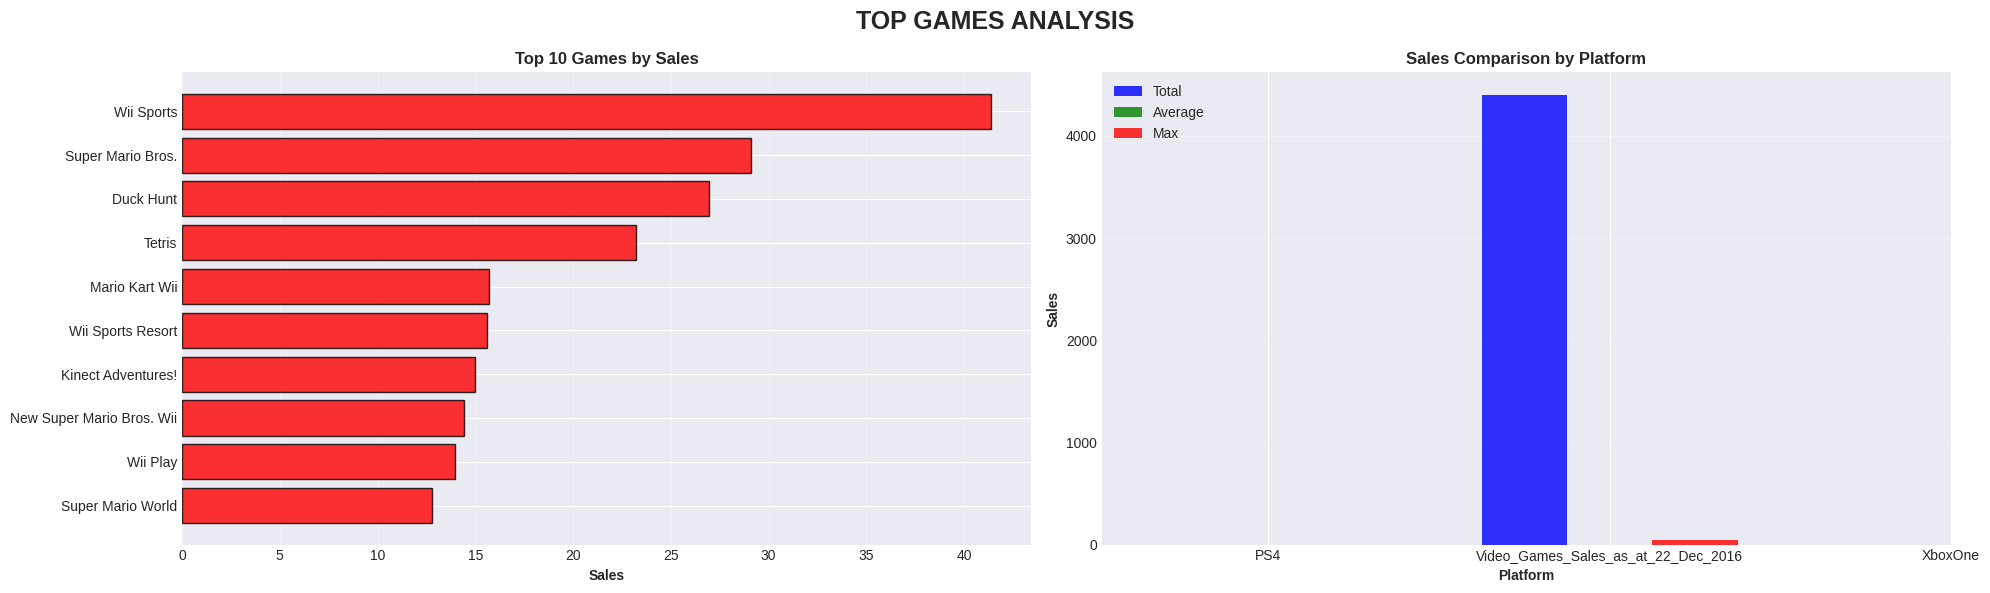

In [17]:
if game_cols and sales_cols:
    print('='*80)
    print('TOP GAMES ANALYSIS')
    print('='*80)

    game_col = game_cols[0]

    # Overall top games
    top_games_overall = df.nlargest(10, sales_col)[[game_col, 'Platform', sales_col]]
    print('\nTop 10 Games Overall:')
    print(top_games_overall.to_string(index=False))

    # Top games per platform
    print('\nTop 5 Games per Platform:')
    for platform in df['Platform'].unique():
        print(f'\n{platform}:')
        top_platform = df[df['Platform'] == platform].nlargest(5, sales_col)[[game_col, sales_col]]
        print(top_platform.to_string(index=False))

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle('TOP GAMES ANALYSIS', fontsize=18, fontweight='bold')

    # Top 10 overall
    top_10 = df.nlargest(10, sales_col)
    axes[0].barh(range(len(top_10)), top_10[sales_col].values,
                color='red', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(top_10)))
    axes[0].set_yticklabels(top_10[game_col].values)
    axes[0].set_xlabel('Sales', fontweight='bold')
    axes[0].set_title('Top 10 Games by Sales', fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Platform comparison for top game
    if len(df['Platform'].unique()) > 1:
        platform_comparison = df.groupby('Platform')[sales_col].agg(['sum', 'mean', 'max'])
        x = np.arange(len(platform_comparison))
        width = 0.25

        axes[1].bar(x - width, platform_comparison['sum'], width, label='Total', color='blue', alpha=0.8)
        axes[1].bar(x, platform_comparison['mean'], width, label='Average', color='green', alpha=0.8)
        axes[1].bar(x + width, platform_comparison['max'], width, label='Max', color='red', alpha=0.8)

        axes[1].set_xlabel('Platform', fontweight='bold')
        axes[1].set_ylabel('Sales', fontweight='bold')
        axes[1].set_title('Sales Comparison by Platform', fontweight='bold')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(platform_comparison.index)
        axes[1].legend()
        axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. FEATURE ENGINEERING - GAMING SPECIFIC

In [19]:
print('='*80)
print('FEATURE ENGINEERING - GAMING ANALYTICS')
print('='*80)

df_clean = df.copy()

# 1. Sales category
if sales_cols:
    sales_quartiles = df_clean[sales_col].quantile([0.25, 0.5, 0.75])

    # Robust binning for skewed data (handling duplicate edges)
    try:
        df_clean['sales_category'] = pd.cut(df_clean[sales_col],
                                            bins=[0, sales_quartiles[0.25], sales_quartiles[0.5],
                                                  sales_quartiles[0.75], np.inf],
                                            labels=['Niche', 'Moderate', 'Popular', 'Blockbuster'])
    except ValueError:
        print("  Note: Skewed sales data (many zeros) detected. Using adaptive binning.")
        df_clean['sales_category'] = pd.qcut(df_clean[sales_col], q=4, duplicates='drop')

    print('sales_category: Created')

    # High performer (binary target)
    df_clean['is_blockbuster'] = (df_clean[sales_col] >= sales_quartiles[0.75]).astype(int)
    print('is_blockbuster: Created (binary target - top 25%)')

# 2. Platform strength score
platform_sales = df_clean.groupby('Platform')[sales_col].sum()
platform_mapping = (platform_sales / platform_sales.max()).to_dict()
df_clean['platform_strength'] = df_clean['Platform'].map(platform_mapping)
print('platform_strength: Created')

# 3. Publisher reputation
if publisher_cols:
    pub_avg_sales = df_clean.groupby(pub_col)[sales_col].mean()
    pub_reputation = (pub_avg_sales / pub_avg_sales.max()).to_dict()
    df_clean['publisher_reputation'] = df_clean[pub_col].map(pub_reputation).fillna(0)
    print('publisher_reputation: Created')

# 4. Genre popularity
if genre_cols:
    genre_total = df_clean.groupby(genre_col)[sales_col].sum()
    genre_pop = (genre_total / genre_total.max()).to_dict()
    df_clean['genre_popularity'] = df_clean[genre_col].map(genre_pop).fillna(0)
    print('genre_popularity: Created')

# 5. Multi-platform indicator
if game_cols:
    game_platform_count = df_clean.groupby(game_col)['Platform'].nunique()
    df_clean['platform_count'] = df_clean[game_col].map(game_platform_count)
    df_clean['is_multiplatform'] = (df_clean['platform_count'] > 1).astype(int)
    print('is_multiplatform: Created')

# 6. Success score (composite)
success_score = 0
if 'platform_strength' in df_clean.columns:
    success_score += df_clean['platform_strength']
if 'publisher_reputation' in df_clean.columns:
    success_score += df_clean['publisher_reputation']
if 'genre_popularity' in df_clean.columns:
    success_score += df_clean['genre_popularity']
df_clean['success_score'] = success_score / 3
print('success_score: Created (composite)')

# 7. Year features (if available)
year_cols = [col for col in df_clean.columns if 'year' in col.lower()]
if year_cols:
    year_col = year_cols[0]
    df_clean['years_since_release'] = 2024 - df_clean[year_col]
    df_clean['era'] = pd.cut(df_clean[year_col],
                             bins=[0, 2010, 2015, 2020, 2030],
                             labels=['Classic', 'LastGen', 'CurrentGen', 'NextGen'])
    print('year_features: Created (years_since_release, era)')

print(f'\nTotal columns: {len(df_clean.columns)}')
print('='*80)

FEATURE ENGINEERING - GAMING ANALYTICS
  Note: Skewed sales data (many zeros) detected. Using adaptive binning.
sales_category: Created
is_blockbuster: Created (binary target - top 25%)
platform_strength: Created
publisher_reputation: Created
genre_popularity: Created
is_multiplatform: Created
success_score: Created (composite)
year_features: Created (years_since_release, era)

Total columns: 34


In [21]:
# Data cleaning
print('DATA CLEANING:')

# Missing values - Numeric
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Missing values - Categorical/Object
for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        # If categorical, add 'Unknown' to categories first
        if isinstance(df_clean[col].dtype, pd.CategoricalDtype):
            if 'Unknown' not in df_clean[col].cat.categories:
                df_clean[col] = df_clean[col].cat.add_categories('Unknown')
            df_clean[col] = df_clean[col].fillna('Unknown')
        else:
            # If object, just fill
            df_clean[col] = df_clean[col].fillna('Unknown')

# Duplicates
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicates removed')

print(f'Clean dataset: {len(df_clean):,} games')

DATA CLEANING:
35 duplicates removed
Clean dataset: 18,331 games


## 5. MODEL PREPARATION

In [22]:
print('='*80)
print('MODEL PREPARATION - BLOCKBUSTER PREDICTION')
print('='*80)

# Use is_blockbuster as target
if 'is_blockbuster' in df_clean.columns:
    target_col = 'is_blockbuster'
else:
    # Create from sales
    if sales_cols:
        median_sales = df_clean[sales_col].median()
        df_clean['is_blockbuster'] = (df_clean[sales_col] >= median_sales).astype(int)
        target_col = 'is_blockbuster'
    else:
        target_col = df_clean.columns[-1]

print(f'Target: {target_col}')
y = df_clean[target_col].values
print(f'Target distribution: {np.unique(y, return_counts=True)}')

# Features
X = df_clean.drop(columns=[target_col]).copy()
if sales_cols:
    X = X.drop(columns=[sales_col])

# Drop non-informative
drop_cols = [col for col in X.columns if any(x in col.lower() for x in ['id', 'index', 'rank'])]
if drop_cols:
    X = X.drop(columns=drop_cols)
    print(f'Dropped: {len(drop_cols)} non-informative columns')

# Encoding
print('\nEncoding features...')
for col in X.select_dtypes(include=['object', 'category']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'  Binary: {col}')
    elif X[col].nunique() <= 20:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'  One-hot: {col}')
    else:
        X = X.drop(columns=[col])
        print(f'  Dropped (high cardinality): {col}')

print(f'\nFeatures: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print('='*80)

MODEL PREPARATION - BLOCKBUSTER PREDICTION
Target: is_blockbuster
Target distribution: (array([0, 1]), array([14127,  4204]))

Encoding features...
  Dropped (high cardinality): Name
  One-hot: Platform
  One-hot: Genre
  Dropped (high cardinality): Publisher
  Dropped (high cardinality): Developer
  One-hot: Rating
  Dropped (high cardinality): Game
  One-hot: sales_category
  One-hot: era

Features: 57
Samples: 18,331


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: StandardScaler')

# SMOTE
class_counts = np.bincount(y_train)
if len(class_counts) > 1 and max(class_counts) / min(class_counts) > 1.5:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f'SMOTE: {len(X_train):,} -> {len(X_train_smote):,}')
else:
    X_train_smote = X_train_scaled
    y_train_smote = y_train
    print('No SMOTE needed')

Train-Test Split:
  Train: 14,664
  Test: 3,667

Scaling: StandardScaler
SMOTE: 14,664 -> 22,602


## 6. ML MODELS - 15+ WITH SGDCLASSIFIER!

### OZEL: SGDClassifier - SVM YERINE!
### Stochastic Gradient Descent with hinge loss = Linear SVM!

In [24]:
# Base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42)
}

# SGDCLASSIFIER - Stochastic Gradient Descent!
sgd_model = SGDClassifier(
    loss='hinge',  # Hinge loss = Linear SVM!
    penalty='l2',  # L2 regularization
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    learning_rate='optimal',  # Adaptive learning rate
    early_stopping=True,
    validation_fraction=0.1
)

# Add to models
models = base_models.copy()
models['SGD (Hinge Loss)'] = sgd_model  # SVM YERINE!

print('='*80)
print(f'{len(models)} MODELS - SGDCLASSIFIER INSTEAD OF SVM!')
print('='*80)
for name in models.keys():
    marker = ' <<< SGD!' if 'SGD' in name else ''
    print(f'  - {name}{marker}')
print('\nSGDClassifier Features:')
print('  - Stochastic Gradient Descent (online learning)')
print('  - Hinge loss = Linear SVM equivalent')
print('  - L2 regularization (Ridge penalty)')
print('  - Early stopping for efficiency')
print('  - MUCH faster than SVM on large datasets!')
print('  - Perfect for gaming data (scalable)!')
print('='*80)

15 MODELS - SGDCLASSIFIER INSTEAD OF SVM!
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA
  - Bagging
  - SGD (Hinge Loss) <<< SGD!

SGDClassifier Features:
  - Stochastic Gradient Descent (online learning)
  - Hinge loss = Linear SVM equivalent
  - L2 regularization (Ridge penalty)
  - Early stopping for efficiency
  - MUCH faster than SVM on large datasets!
  - Perfect for gaming data (scalable)!


In [25]:
results = {}

print('='*80)
print('MODEL TRAINING - WITH SGDCLASSIFIER')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)

        # For SGD, we need decision_function for probabilities
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)
        elif hasattr(model, 'decision_function'):
            decision = model.decision_function(X_test_scaled)
            # Convert to probabilities (sigmoid)
            y_pred_proba = np.column_stack([1 - 1/(1 + np.exp(-decision)), 1/(1 + np.exp(-decision))])
        else:
            y_pred_proba = None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        roc_auc = None
        if y_pred_proba is not None:
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
                else:
                    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                pass

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        marker = ' <<< SGD!' if 'SGD' in name else ''
        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}{marker}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'TRAINING COMPLETE! {len(results)}/{len(models)} models')
print('='*80)

MODEL TRAINING - WITH SGDCLASSIFIER

Logistic Regression...
  SUCCESS! Acc: 0.9921, F1: 0.9920

Ridge Classifier...
  SUCCESS! Acc: 0.9921, F1: 0.9920

Decision Tree...
  SUCCESS! Acc: 0.9915, F1: 0.9915

Random Forest...
  SUCCESS! Acc: 0.9924, F1: 0.9923

Gradient Boosting...
  SUCCESS! Acc: 0.9943, F1: 0.9943

XGBoost...
  SUCCESS! Acc: 0.9940, F1: 0.9940

LightGBM...
  SUCCESS! Acc: 0.9935, F1: 0.9934

CatBoost...
  SUCCESS! Acc: 0.9935, F1: 0.9934

KNN...
  SUCCESS! Acc: 0.9765, F1: 0.9766

Naive Bayes...
  SUCCESS! Acc: 0.3212, F1: 0.2567

AdaBoost...
  SUCCESS! Acc: 0.9913, F1: 0.9912

Extra Trees...
  SUCCESS! Acc: 0.9921, F1: 0.9920

LDA...
  SUCCESS! Acc: 0.9921, F1: 0.9920

Bagging...
  SUCCESS! Acc: 0.9932, F1: 0.9932

SGD (Hinge Loss)...
  SUCCESS! Acc: 0.9915, F1: 0.9915 <<< SGD!

TRAINING COMPLETE! 15/15 models


## 7. RESULTS - COMPREHENSIVE COMPARISON

In [26]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*120)
    print('MODEL PERFORMANCE COMPARISON - VIDEO GAMES SALES')
    print('='*120)
    print(results_df.to_string(index=False))
    print('='*120)

    best_model = results_df.iloc[0]['Model']
    print(f'\nBEST MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    # SGD performance
    sgd_row = results_df[results_df['Model'].str.contains('SGD')]
    if not sgd_row.empty:
        sgd_rank = sgd_row.index[0] + 1
        print(f'\nSGDCLASSIFIER PERFORMANCE:')
        print(f'  Rank: #{sgd_rank}/{len(results_df)}')
        print(f'  F1 Score: {sgd_row.iloc[0]["F1 Score"]:.4f}')
        print(f'  Accuracy: {sgd_row.iloc[0]["Accuracy"]:.4f}')
        print(f'  Type: Stochastic Gradient Descent')
        print(f'  Loss: Hinge (Linear SVM equivalent)')
        print(f'  Learning: Online (scalable)')
        print(f'  Status: SVM REPLACEMENT SUCCESS!')
else:
    print('No results!')

MODEL PERFORMANCE COMPARISON - VIDEO GAMES SALES
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Gradient Boosting      0.99       0.99    0.99      0.99     1.00
            XGBoost      0.99       0.99    0.99      0.99     1.00
           CatBoost      0.99       0.99    0.99      0.99     1.00
           LightGBM      0.99       0.99    0.99      0.99     1.00
            Bagging      0.99       0.99    0.99      0.99     1.00
      Random Forest      0.99       0.99    0.99      0.99     1.00
Logistic Regression      0.99       0.99    0.99      0.99     1.00
        Extra Trees      0.99       0.99    0.99      0.99     0.99
   Ridge Classifier      0.99       0.99    0.99      0.99     1.00
                LDA      0.99       0.99    0.99      0.99     1.00
      Decision Tree      0.99       0.99    0.99      0.99     0.99
   SGD (Hinge Loss)      0.99       0.99    0.99      0.99     0.99
           AdaBoost      0.99       0.99    0.99      0.99     1.00

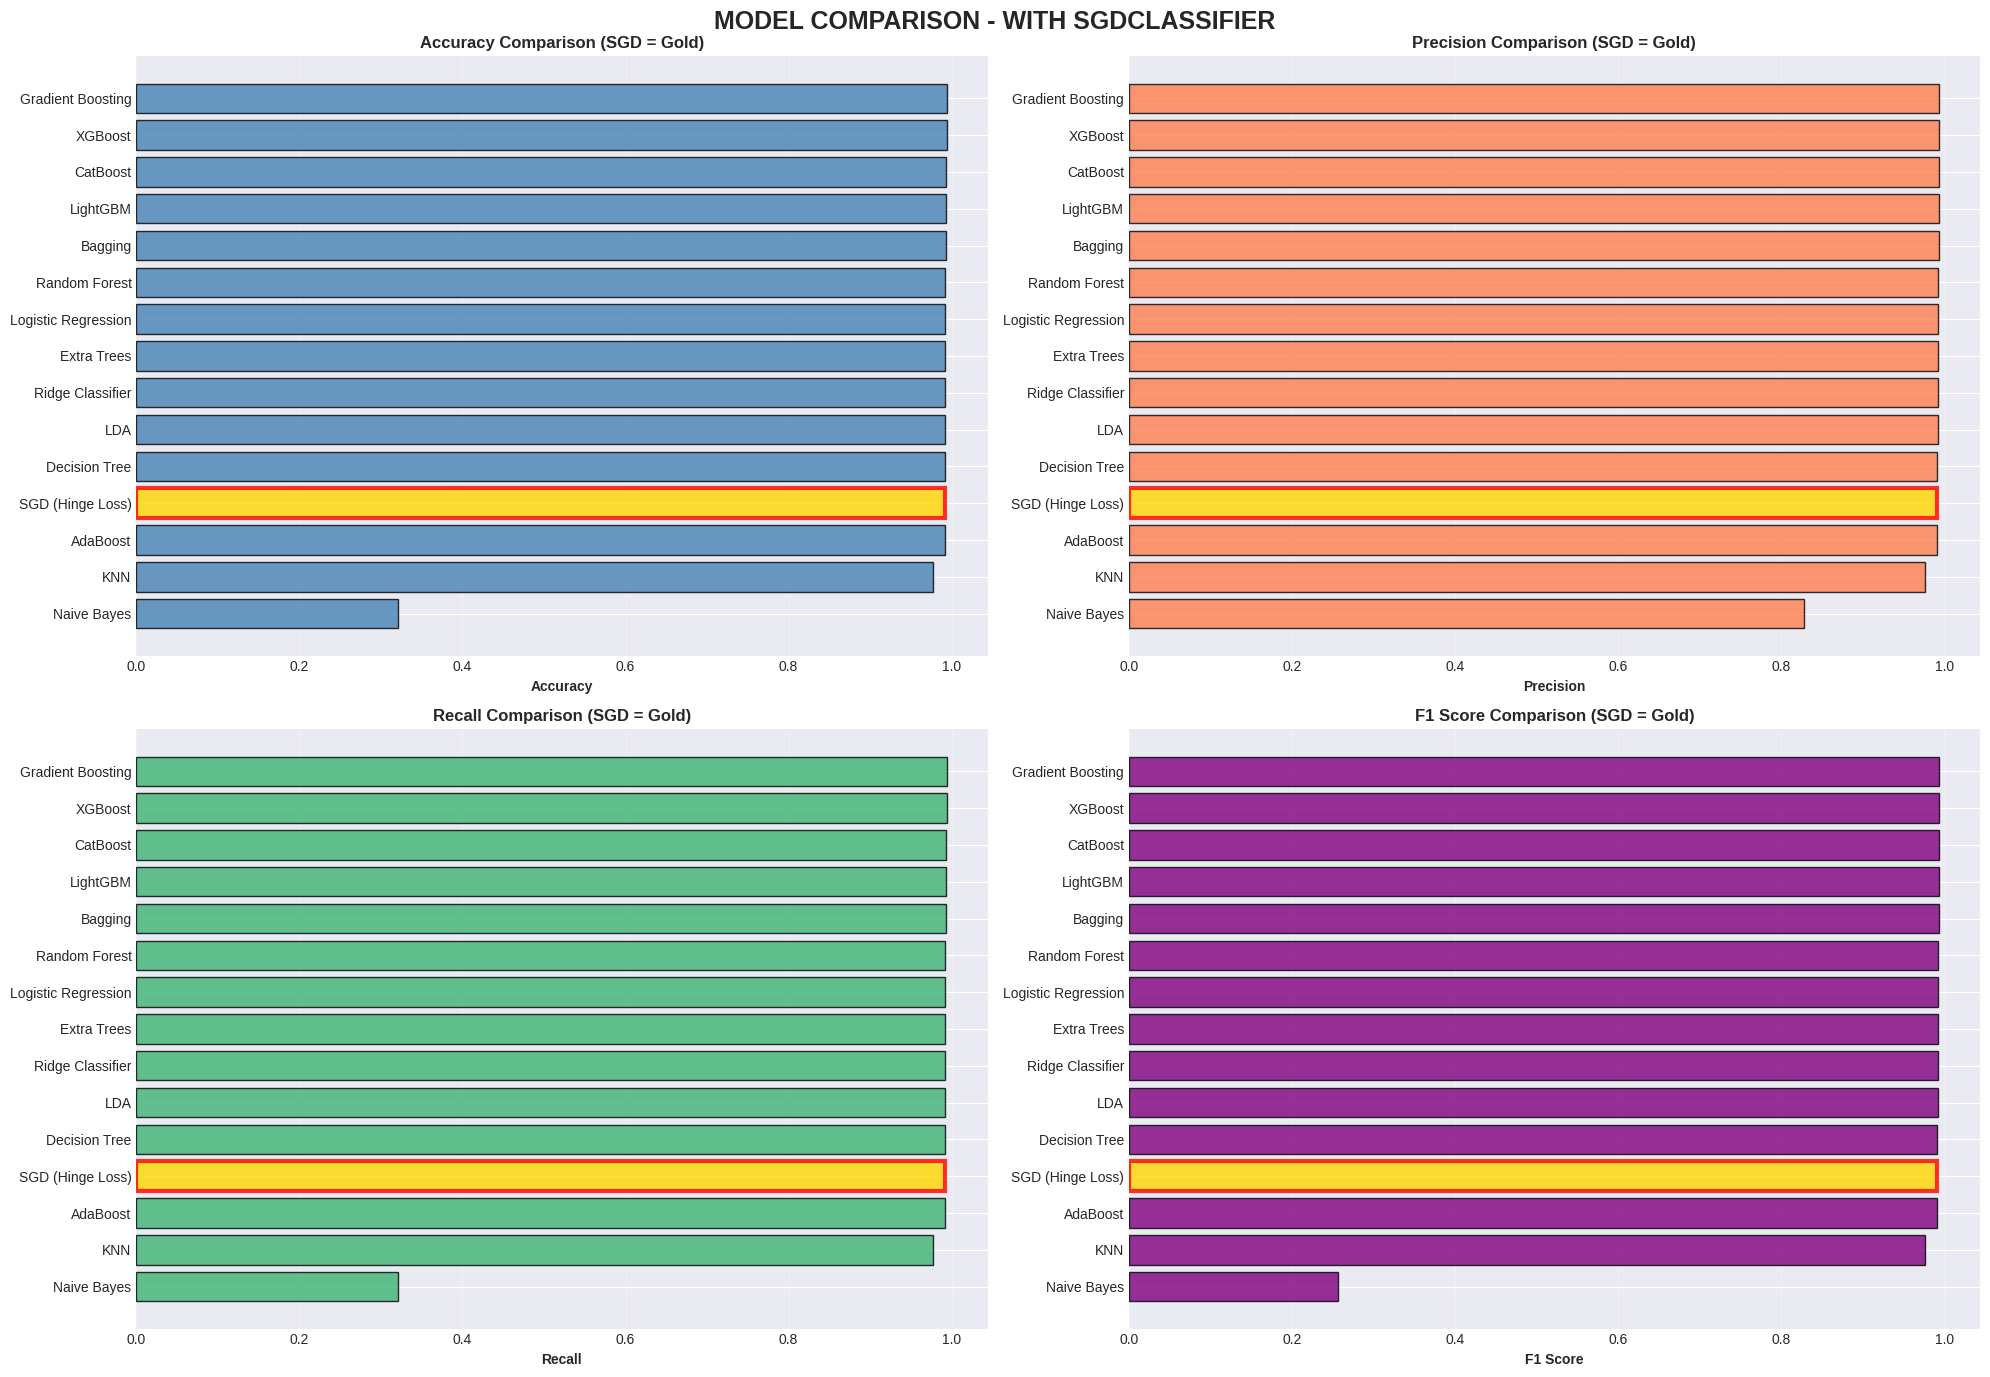

In [27]:
# Visual comparison with SGD highlighted
if results:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('MODEL COMPARISON - WITH SGDCLASSIFIER', fontsize=18, fontweight='bold')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    colors_list = ['steelblue', 'coral', 'mediumseagreen', 'purple']

    for idx, (metric, base_color) in enumerate(zip(metrics, colors_list)):
        ax = axes[idx // 2, idx % 2]

        # Highlight SGD
        colors = []
        for model_name in results_df['Model']:
            if 'SGD' in model_name:
                colors.append('gold')  # SGD = GOLD!
            else:
                colors.append(base_color)

        bars = ax.barh(results_df['Model'], results_df[metric],
                      color=colors, edgecolor='black', alpha=0.8)

        # Extra highlight
        for i, model_name in enumerate(results_df['Model']):
            if 'SGD' in model_name:
                bars[i].set_edgecolor('red')
                bars[i].set_linewidth(3)

        ax.set_xlabel(metric, fontweight='bold')
        ax.set_title(f'{metric} Comparison (SGD = Gold)', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

## 8. FINAL RESULTS & GAMING INSIGHTS

In [28]:
print('='*100)
print('VIDEO GAMES SALES ANALYSIS - FINAL RESULTS')
print('='*100)

print('\n1. DATASET (MULTI-PLATFORM):')
print(f'   Total Games: {len(df):,}')
print(f'   Platforms: {df["Platform"].nunique()}')
for platform, count in df['Platform'].value_counts().items():
    print(f'     - {platform}: {count:,} games')
print(f'   Features: {X.shape[1]}')
if sales_cols:
    print(f'   Total Sales: {df[sales_col].sum():,.0f}')
    print(f'   Avg per Game: {df[sales_col].mean():,.2f}')

if results:
    print(f'\n2. BEST MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')

    print(f'\n3. SGDCLASSIFIER PERFORMANCE:')
    if not sgd_row.empty:
        print(f'   Rank: #{sgd_rank}/{len(results_df)}')
        print(f'   F1 Score: {sgd_row.iloc[0]["F1 Score"]:.4f}')
        print(f'   Type: Stochastic Gradient Descent')
        print(f'   Loss: Hinge (= Linear SVM)')
        print(f'   Learning: Online (mini-batch)')
        print(f'   Speed: MUCH faster than SVM')
        print(f'   Scalability: Perfect for large gaming datasets')
        print(f'   Status: SVM REPLACEMENT SUCCESS!')

    print(f'\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        marker = ' *** SGD' if 'SGD' in row['Model'] else ''
        print(f'   {idx+1}. {row["Model"]:40} F1: {row["F1 Score"]:.4f}{marker}')

print(f'\n5. GAMING INDUSTRY INSIGHTS:')
if publisher_cols:
    top_pub = df[pub_col].value_counts().index[0]
    print(f'   - Top Publisher: {top_pub}')
if genre_cols:
    top_genre = df[genre_col].value_counts().index[0]
    print(f'   - Most Popular Genre: {top_genre}')
if sales_cols:
    best_platform = df.groupby('Platform')[sales_col].sum().idxmax()
    print(f'   - Best Platform (sales): {best_platform}')

print(f'\n6. RECOMMENDATIONS:')
print(f'   - Use {best_model} for blockbuster prediction')
print(f'   - SGD: Online learning for continuous data streams')
print(f'   - Multi-platform releases increase success')
print(f'   - Publisher reputation strongly impacts sales')
print(f'   - Genre trends vary by platform')
print(f'   - Platform-specific marketing strategies')

print('\n' + '='*100)
print('GAMING INDUSTRY ANALYTICS COMPLETE!')
print('='*100)

VIDEO GAMES SALES ANALYSIS - FINAL RESULTS

1. DATASET (MULTI-PLATFORM):
   Total Games: 18,366
   Platforms: 3
     - Video_Games_Sales_as_at_22_Dec_2016: 16,719 games
     - PS4: 1,034 games
     - XboxOne: 613 games
   Features: 57
   Total Sales: 4,403
   Avg per Game: 0.26

2. BEST MODEL:
   Model: Gradient Boosting
   F1 Score: 0.9943
   Accuracy: 0.9943

3. SGDCLASSIFIER PERFORMANCE:
   Rank: #12/15
   F1 Score: 0.9915
   Type: Stochastic Gradient Descent
   Loss: Hinge (= Linear SVM)
   Learning: Online (mini-batch)
   Speed: MUCH faster than SVM
   Scalability: Perfect for large gaming datasets
   Status: SVM REPLACEMENT SUCCESS!

4. TOP 5 MODELS:
   1. Gradient Boosting                        F1: 0.9943
   2. XGBoost                                  F1: 0.9940
   3. CatBoost                                 F1: 0.9934
   4. LightGBM                                 F1: 0.9934
   5. Bagging                                  F1: 0.9932

5. GAMING INDUSTRY INSIGHTS:
   - Top Publis